In [5]:
import torch
from torchvision import datasets
import matplotlib.pyplot as plt
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Problem 1 - CNN on MNIST

In [ ]:
data_path="/content/MNIST"

In [ ]:
raw_mnist_data = datasets.MNIST(
    root=data_path,
    download=True,
    transform=transforms.ToTensor()
)

load=torch.utils.data.DataLoader(raw_mnist_data, batch_size=60000)
data=next(iter(load))[0]

print(data.shape)

m=data.mean()
s=data.std()

print(m,s)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.7MB/s]


torch.Size([60000, 1, 28, 28])
tensor(0.1307) tensor(0.3081)


In [ ]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081),)
])

train_data = datasets.MNIST(
    root=data_path+"/train_data",
    download=True,
    train=True,
    transform=transform
)

test_data = datasets.MNIST(
    root=data_path+"/test_data",
    download=True,
    train=False,
    transform=transform
)

print(train_data.data.shape)
print(test_data.data.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.37MB/s]
100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])


In [ ]:
train=torch.utils.data.DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test=torch.utils.data.DataLoader(
    test_data,
    batch_size=1000,
    shuffle=False
)

In [ ]:
class NetNormDrop(nn.Module):
  def __init__(self,n_chans=64):
    super().__init__()
    self.n_channel=n_chans
    self.conv1=nn.Conv2d(1, n_chans,kernel_size=3,padding=1)
    self.conv1_bn=nn.BatchNorm2d(num_features=n_chans)
    self.conv1_dropout=nn.Dropout2d(p=0.4)

    self.conv2=nn.Conv2d(n_chans, n_chans//2,kernel_size=3,padding=1)
    self.conv2_bn=nn.BatchNorm2d(num_features=n_chans//2)
    self.conv2_dropout=nn.Dropout(p=0.4)

    self.fc1=nn.Linear(7*7*(n_chans//2),32)
    self.fc2=nn.Linear(32,10)

  def forward(self,x):
    out=self.conv1(x)
    out=self.conv1_bn(out)
    out=F.relu(out)
    out=F.max_pool2d(out,2)
    out=self.conv1_dropout(out)

    out=self.conv2(out)
    out=self.conv2_bn(out)
    out=F.relu(out)
    out=F.max_pool2d(out,2)
    out=self.conv2_dropout(out)

    out=out.view(out.size(0),-1)
    out=F.relu(self.fc1(out))
    out=self.fc2(out)

    return out

In [ ]:
def training_loop(n_epochs, train_loader,optimizer,loss_fn,model):
  for i in range(1,n_epochs):
    loss_train=0.0
    for img,l in train_loader:
      img=img.to(device)
      l=l.to(device)
      pred=model(img)
      loss=loss_fn(pred,l)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      loss_train+=loss.item()
    print(f"Train Loss {loss_train/len(train_loader)}")

In [ ]:
model=NetNormDrop().to(device)
optimizer=optim.Adam(model.parameters(),lr=1e-2)
loss_fn=nn.CrossEntropyLoss()

training_loop(
    n_epochs=20,
    optimizer=optimizer,
    model=model,
    train_loader=train,
    loss_fn=loss_fn
)

Train Loss 0.24938839248844238
Train Loss 0.12845808110767798
Train Loss 0.11064511263218801
Train Loss 0.10264992311389358
Train Loss 0.09565792564076306
Train Loss 0.09130816075847602
Train Loss 0.08792205978267348
Train Loss 0.08433212972144837
Train Loss 0.08077391848933183
Train Loss 0.07936411694055602
Train Loss 0.0787774648982535
Train Loss 0.07558127433242304
Train Loss 0.07309221716829514
Train Loss 0.07275432057560546
Train Loss 0.07355926308293403
Train Loss 0.06952983408911662
Train Loss 0.06914317144923952
Train Loss 0.06598092646867748
Train Loss 0.06308320904898244


In [ ]:
correct=0
total=0

with torch.no_grad():
  for img,l in test:
    img,l=img.to(device),l.to(device)
    out=model(img)
    _,preds=torch.max(out,1)
    total+=l.size(0)
    correct+=(preds==l).sum().item()

acc=100*correct/total
print(f"Test accuracu: {acc:.2f}%")

Test accuracu: 97.56%


# Problem 6 - Resnet on CIFAR10

In [6]:
data_path="/content/data/CIFAR10"

In [7]:
cifar10 = datasets.CIFAR10(
    data_path,
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

cifar10_val=datasets.CIFAR10(
    data_path,
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 170M/170M [00:03<00:00, 49.2MB/s]


In [8]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [9]:
class_names[1]

'automobile'

In [10]:
img,label=cifar10[100]
img,label,class_names[label]

(tensor([[[0.8353, 0.8275, 0.8275,  ..., 0.5922, 0.5922, 0.5843],
          [0.8392, 0.8314, 0.8314,  ..., 0.5961, 0.5961, 0.5922],
          [0.8471, 0.8392, 0.8353,  ..., 0.6000, 0.6000, 0.5922],
          ...,
          [0.5686, 0.5333, 0.5608,  ..., 0.8471, 0.7686, 0.7176],
          [0.5451, 0.5059, 0.5059,  ..., 0.8902, 0.8745, 0.8196],
          [0.5373, 0.5608, 0.5333,  ..., 0.8196, 0.8510, 0.8941]],
 
         [[0.8980, 0.8902, 0.8902,  ..., 0.6824, 0.6824, 0.6745],
          [0.8980, 0.8902, 0.8902,  ..., 0.6863, 0.6863, 0.6824],
          [0.8980, 0.8902, 0.8902,  ..., 0.6902, 0.6902, 0.6824],
          ...,
          [0.6235, 0.5804, 0.5961,  ..., 0.8510, 0.7725, 0.7176],
          [0.6000, 0.5569, 0.5451,  ..., 0.8941, 0.8784, 0.8196],
          [0.5961, 0.6078, 0.5686,  ..., 0.8196, 0.8510, 0.8941]],
 
         [[0.9490, 0.9412, 0.9412,  ..., 0.8078, 0.8078, 0.8000],
          [0.9451, 0.9373, 0.9373,  ..., 0.8118, 0.8118, 0.8039],
          [0.9373, 0.9294, 0.9294,  ...,

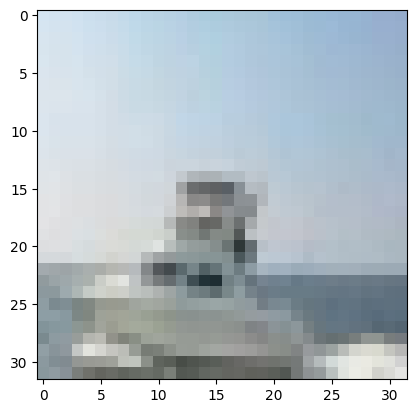

In [11]:
plt.imshow(img.permute(1,2,0))

In [12]:
img.shape

torch.Size([3, 32, 32])

In [13]:
imgs=torch.stack([img for img,_ in cifar10],dim=3) #dim=x places extra dim at position x
imgs.shape

torch.Size([3, 32, 32, 50000])

In [14]:
mean =imgs.view(3,-1).mean(dim=1)
mean.tolist()

[0.4913996458053589, 0.48215845227241516, 0.44653093814849854]

In [15]:
std=imgs.view(3,-1).std(dim=1)
std.tolist()

[0.24703224003314972, 0.24348513782024384, 0.26158785820007324]

In [16]:
cifar10 = datasets.CIFAR10(
    data_path,
    train=True,
    download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean,std)
    ])
)

cifar10_val=datasets.CIFAR10(
    data_path,
    train=False,
    download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean,std)
    ])
)

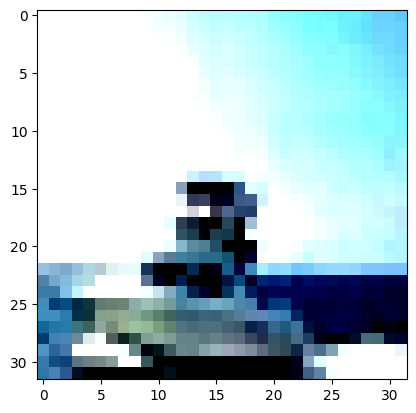

In [17]:
img,_=cifar10[100]

plt.imshow(img.permute(1,2,0))

# Resource Limitation, reducing classses to 2 (automobile and truck)

In [18]:
label_map={1:0,9:1}
class_names = ['automobile', 'truck']

cifar2_train=[(image,label_map[label]) for image, label in cifar10
        if label in [1,9]]

cifar2_val=[(image,label_map[label])for image, label in cifar10_val
            if label in [1,9]]

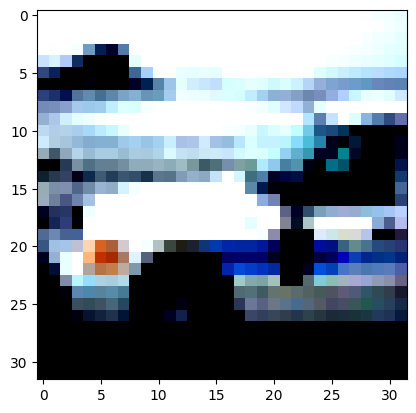

In [21]:
img,_=cifar2_train[100]

plt.imshow(img.permute(1,2,0))

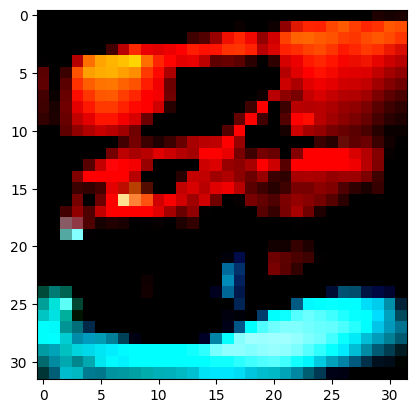

In [25]:
img,l=cifar2_train[10]

plt.imshow(img.permute(1,2,0))

In [26]:
print(type(l))

<class 'int'>


In [19]:
class ResBlock(nn.Module):
  def __init__(self,n_chans):
    super().__init__()
    self.conv1=nn.Conv2d(n_chans,n_chans,kernel_size=3,padding=1,bias=False)
    self.bn1=nn.BatchNorm2d(n_chans)
    self.conv2=nn.Conv2d(n_chans,n_chans,kernel_size=3,padding=1,bias=False)
    self.bn2=nn.BatchNorm2d(n_chans)

  def forward(self,x):
    out=F.relu(self.bn1(self.conv1(x)))
    out=self.bn2(self.conv2(out))
    return F.relu(out+x)

In [20]:
class ResNet(nn.Module):
  def __init__(self,n_chans1=64,n_blocks=3,n_classes=2):
    super().__init__()
    self.conv1=nn.Conv2d(3,n_chans1,kernel_size=3,padding=1,bias=False)
    self.bn1=nn.BatchNorm2d(n_chans1)
    self.resblocks=nn.Sequential(
        *(n_blocks*[ResBlock(n_chans1)]) # * unpacks the list of blcoks which is equivalent to nn.Sequential(block1, block2, block3)
    )
    self.fc=nn.Linear(n_chans1,n_classes)

  def forward(self,x):
    out=F.relu(self.bn1(self.conv1(x)))
    out=self.resblocks(out)
    out=F.adaptive_avg_pool2d(out,(1,1)) #global avg pooling
    out=out.view(out.size(0),-1)
    out=self.fc(out)
    return out

In [27]:
def training_loop(n_epochs, train_loader,optimizer,loss_fn,model):
  model.train()
  for i in range(1,n_epochs):
    loss_train=0.0
    correct=0
    total=0
    for img,l in train_loader:
      img=img.to(device)
      l=torch.tensor(l, dtype=torch.long,device=device)

      optimizer.zero_grad()
      pred=model(img)
      loss=loss_fn(pred,l)
      loss.backward()
      optimizer.step()

      loss_train+=loss.item()*img.size(0)
      _,predicted=torch.max(pred,1)
      total+=l.size(0)
      correct+=(predicted==l).sum().item()
    epoch_loss = loss_train / total
    epoch_acc = correct / total
    print(f"Epoch {i+1}/{n_epochs}, Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}")

In [29]:
train_loader=torch.utils.data.DataLoader(cifar2_train,
                                         batch_size=32,
                                         shuffle=True)

In [30]:
model=ResNet(n_chans1=64,n_blocks=3,n_classes=2).to(device)
optimizer=optim.SGD(model.parameters(),lr=0.1,momentum=0.9,weight_decay=1e-4)
loss_fn=nn.CrossEntropyLoss()

training_loop(
    n_epochs=20,
    optimizer=optimizer,
    model=model,
    train_loader=train_loader,
    loss_fn=loss_fn
)

/tmp/ipykernel_2618/3155056328.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  l=torch.tensor(l, dtype=torch.long,device=device)


Epoch 2/20, Loss: 0.7199, Acc: 0.5630
Epoch 3/20, Loss: 0.5977, Acc: 0.6865
Epoch 4/20, Loss: 0.5324, Acc: 0.7360
Epoch 5/20, Loss: 0.4833, Acc: 0.7757
Epoch 6/20, Loss: 0.4409, Acc: 0.7983
Epoch 7/20, Loss: 0.4009, Acc: 0.8248
Epoch 8/20, Loss: 0.3670, Acc: 0.8344
Epoch 9/20, Loss: 0.3270, Acc: 0.8614
Epoch 10/20, Loss: 0.2891, Acc: 0.8796
Epoch 11/20, Loss: 0.2511, Acc: 0.8985
Epoch 12/20, Loss: 0.2452, Acc: 0.9004
Epoch 13/20, Loss: 0.2485, Acc: 0.8980
Epoch 14/20, Loss: 0.2046, Acc: 0.9176
Epoch 15/20, Loss: 0.1942, Acc: 0.9222
Epoch 16/20, Loss: 0.1790, Acc: 0.9276
Epoch 17/20, Loss: 0.1695, Acc: 0.9347
Epoch 18/20, Loss: 0.1653, Acc: 0.9338
Epoch 19/20, Loss: 0.1645, Acc: 0.9340
Epoch 20/20, Loss: 0.1523, Acc: 0.9397
